# LeCroy TRC Waveform Examples

**April 2026**

This notebook demonstrates the supported LeCroy `.trc` files in the repository.  The checked-in artifacts cover both an older `LECROY_1_0` style file and a newer SCPI-prefixed `LECROY_2_3` capture.

In [1]:
%config InlineBackend.figure_format = 'retina'

import io

import numpy as np
import matplotlib.pyplot as plt
import requests
from RigolWFM import Wfm

repo = 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/'

def sample_url(relative_path: str) -> str:
    return repo + relative_path

def _time_scale(times):
    span = float(abs(times[-1] - times[0])) if len(times) > 1 else 1.0
    if span >= 1e-3:
        return 1e3, 'ms'
    if span >= 1e-6:
        return 1e6, 'us'
    if span >= 1e-9:
        return 1e9, 'ns'
    return 1e12, 'ps'

def _volt_scale(values):
    peak = max(float(np.max(np.abs(v))) for v in values) if values else 1.0
    if peak >= 1.0:
        return 1.0, 'V'
    if peak >= 1e-3:
        return 1e3, 'mV'
    if peak >= 1e-6:
        return 1e6, 'uV'
    return 1e9, 'nV'

def plot_analog_channels(w, title=None, max_points=5000):
    active = [ch for ch in w.channels if ch.times is not None and ch.volts is not None]
    if not active:
        print('No analog channels are enabled in this capture.')
        return

    colors = ['green', 'red', 'blue', 'orange']
    t_scale, t_unit = _time_scale(active[0].times)
    v_scale, v_unit = _volt_scale([ch.volts for ch in active])

    fig, axes = plt.subplots(len(active), 1, sharex=True, figsize=(10, 2.5 * len(active)))
    if len(active) == 1:
        axes = [axes]

    for ax, ch, color in zip(axes, active, colors):
        stride = max(len(ch.times) // max_points, 1)
        ax.plot(ch.times[::stride] * t_scale, ch.volts[::stride] * v_scale, color=color)
        ax.set_ylabel(v_unit)
        ax.set_title(f'CH{ch.channel_number}  {ch.points} points')
        ax.grid(True)

    axes[-1].set_xlabel(f'Time ({t_unit})')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_logic_window(w, names=None, start=0, stop=4000, title=None):
    if not w.logic_channels:
        print('No logic channels are enabled in this capture.')
        return

    if names is None:
        names = list(w.logic_channels)

    if w.logic_times is None:
        times = np.arange(len(next(iter(w.logic_channels.values()))), dtype=np.float64)
    else:
        times = w.logic_times

    stop = min(stop, len(times))
    t_scale, t_unit = _time_scale(times[start:stop])

    fig, axes = plt.subplots(len(names), 1, sharex=True, figsize=(10, 1.6 * len(names)))
    if len(names) == 1:
        axes = [axes]

    colors = ['green', 'red', 'blue', 'orange', 'purple', 'brown']
    for ax, name, color in zip(axes, names, colors):
        trace = w.logic_channels[name]
        ax.step(times[start:stop] * t_scale, trace[start:stop], where='post', color=color)
        ax.set_ylim(-0.2, 1.2)
        ax.set_yticks([0, 1])
        ax.set_ylabel(name)
        ax.grid(True)

    axes[-1].set_xlabel(f'Time ({t_unit})')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## `trace1.000` - Legacy `LECROY_1_0` capture

In [2]:
filename = 'trc/trace1.000'
w = Wfm.from_url(sample_url(filename), 'LeCroy')
print(w.describe())

    General:
        File Model   = LeCroy 7200 DSO
        User Model   = LeCroy
        Parser Model = lecroy_trc
        Firmware     = unknown
        Filename     = trace1.000
        Channels     = [1]

    Trigger:
        Derived Level (CH1) = -2.34  V

     Channel 1:
         Coupling =  unknown
            Scale =    49.80 mV/div
           Offset =     2.50  V
            Probe =       1X
         Inverted =    False

        Time Base =  500.200 ns/div
           Offset =    0.000  s
            Delta = 1000.000 ps/point
           Points =     5002

         Count    = [        1,        2,        3  ...      5001,     5002]
           Raw    = [      102,      103,      104  ...        51,       52]
           Times  = [-1.570 µs,-1.569 µs,-1.568 µs  ...  3.430 µs, 3.431 µs]
           Volts  = [ -2.34  V, -2.34  V, -2.34  V  ...  -2.42  V, -2.42  V]




downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/trc/trace1.000'


### Plot the decoded waveform

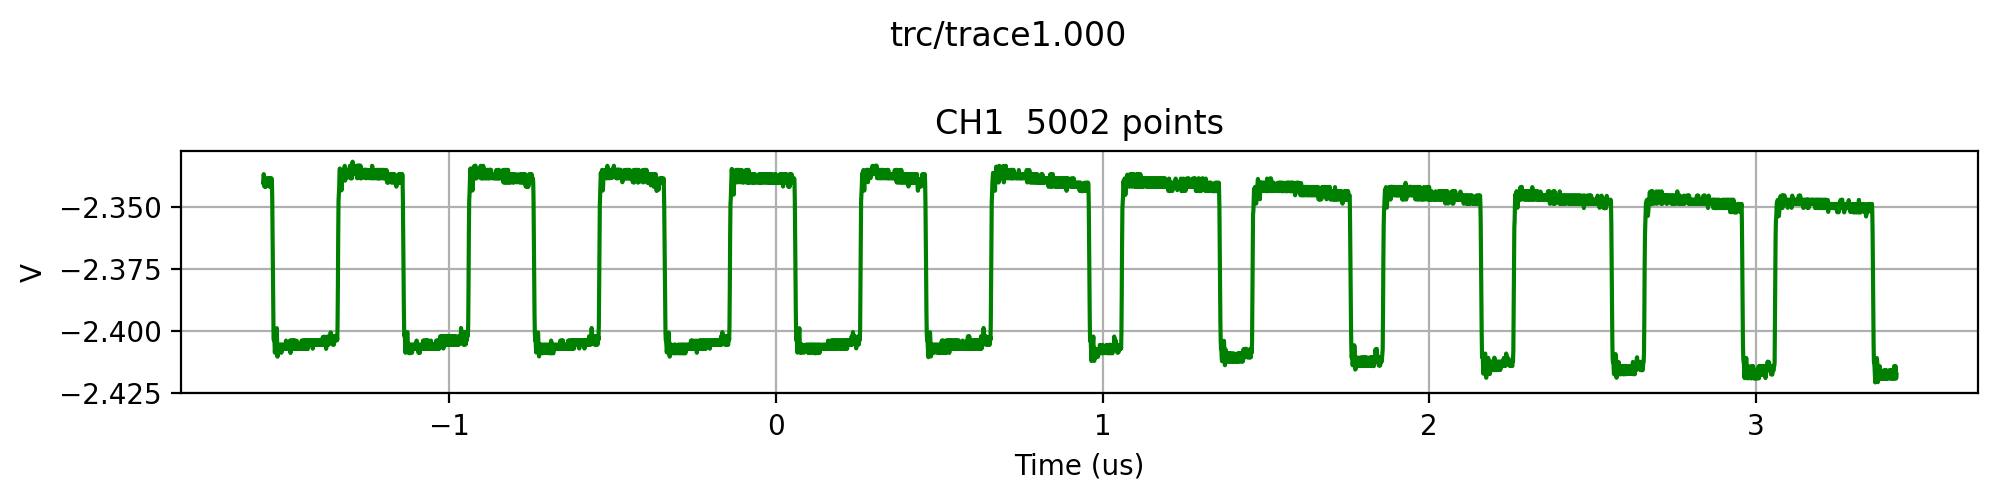

In [3]:
plot_analog_channels(w, title=filename)

## `lecroy_2.trc` - SCPI-prefixed `LECROY_2_3` capture

In [4]:
filename = 'trc/lecroy_2.trc'
w = Wfm.from_url(sample_url(filename), 'LeCroy')
print(w.describe())

    General:
        File Model   = LECROYWP254HD-MS
        User Model   = LeCroy
        Parser Model = lecroy_trc
        Firmware     = unknown
        Filename     = lecroy_2.trc
        Channels     = [2]

    Trigger:
        Derived Level (CH2) = 328.41 mV

     Channel 2:
         Coupling =  unknown
            Scale =     4.97 mV/div
           Offset =  -330.00 mV
            Probe =       1X
         Inverted =    False

        Time Base =    1.000 ms/div
           Offset =    0.000  s
            Delta =  100.000 ns/point
           Points =   100002

         Count    = [        1,        2,        3  ...    100001,   100002]
           Raw    = [      255,      255,      254  ...       254,      255]
           Times  = [-1.000 ms,-999.968 µs,-999.868 µs  ...  9.000 ms, 9.000 ms]
           Volts  = [329.98 mV,329.87 mV,329.75 mV  ... 329.74 mV,329.94 mV]




downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/trc/lecroy_2.trc'


### Plot the active channel

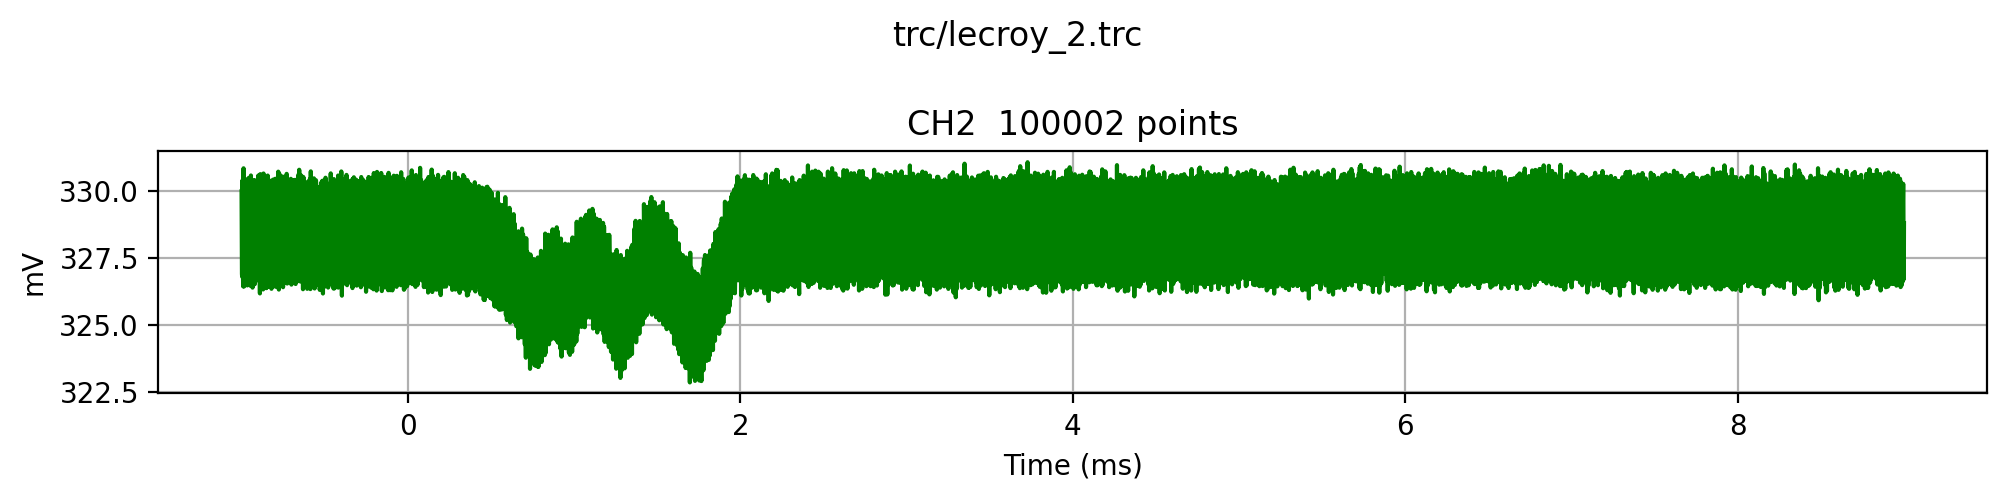

In [5]:
plot_analog_channels(w, title=filename, max_points=8000)

### Compare the two time bases

In [6]:
legacy = Wfm.from_url(sample_url('trc/trace1.000'), 'LeCroy')
modern = Wfm.from_url(sample_url('trc/lecroy_2.trc'), 'LeCroy')
print('Legacy delta: ', legacy.channels[0].seconds_per_point, 's/point')
print('Modern delta: ', modern.channels[0].seconds_per_point, 's/point')
print('Legacy points:', legacy.channels[0].points)
print('Modern points:', modern.channels[0].points)

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/trc/trace1.000'
downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/trc/lecroy_2.trc'


Legacy delta:  9.999999717180685e-10 s/point
Modern delta:  1.0000000116860974e-07 s/point
Legacy points: 5002
Modern points: 100002
